# Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
 
warnings.filterwarnings('ignore')
np.random.seed(42)   # reproducibility for all synthetic injections
 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})
 
# ── Helper: report current DataFrame memory usage ─────────────────────────
def report_memory(df, label=''):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"  Memory usage {label}: {mb:.1f} MB  ({len(df):,} rows)")
 
print("=" * 65)
print("PRT840 – UNRR Framework | Interim Submission v3")
print("Memory-Optimised: Stratified Sample + Dtype Reduction")
print("=" * 65)

PRT840 – UNRR Framework | Interim Submission v3
Memory-Optimised: Stratified Sample + Dtype Reduction


# Stratified loading and D Type optimisation

In [7]:
# Columns to keep — drop heavy unused text columns at read time 
COLS_TO_USE = [
    'marketplace', 'customer_id', 'review_id', 'product_id',
    'product_category', 'star_rating', 'helpful_votes', 'total_votes',
    'vine', 'verified_purchase', 'review_body', 'review_date'
]

SAMPLE_EVERY_NTH = 5   # ← change to 3 (33%) or 10 (10%) if needed
 
df = pd.read_csv(
    'amazon_reviews_books.csv',
    usecols=COLS_TO_USE,
    skiprows=lambda i: i > 0 and i % SAMPLE_EVERY_NTH != 0,
    low_memory=False
)
 
print(f"  Raw sample shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Sample rate        : 1 in every {SAMPLE_EVERY_NTH} rows (~{100//SAMPLE_EVERY_NTH}%)")
report_memory(df, 'BEFORE dtype optimisation')


  Raw sample shape   : 621,074 rows × 12 columns
  Sample rate        : 1 in every 5 rows (~20%)
  Memory usage BEFORE dtype optimisation: 843.1 MB  (621,074 rows)


In [8]:
# Dtype optimisation 
print("\n  Applying dtype optimisation...")
 
# Coerce numerics first so casting works cleanly
df['star_rating']   = pd.to_numeric(df['star_rating'],   errors='coerce')
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0)
df['total_votes']   = pd.to_numeric(df['total_votes'],   errors='coerce').fillna(0)
 
# Now downcast to smaller types
df['star_rating']   = df['star_rating'].astype('Int8')     # nullable int, handles NaN
df['helpful_votes'] = df['helpful_votes'].astype('int32')
df['total_votes']   = df['total_votes'].astype('int32')
 
# Convert low-cardinality string columns to category (huge RAM saving)
for col in ['verified_purchase', 'marketplace', 'product_category', 'vine']:
    if col in df.columns:
        df[col] = df[col].astype('category')
 
report_memory(df, 'AFTER dtype optimisation')
print(f"\n  Columns loaded     : {list(df.columns)}")
print(f"\n  Dtypes:\n{df.dtypes}")
print(f"\n  First 3 rows:\n{df.head(3)}")
print(f"\n  Missing values:\n{df.isnull().sum()}")


  Applying dtype optimisation...
  Memory usage AFTER dtype optimisation: 709.6 MB  (621,074 rows)

  Columns loaded     : ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_body', 'review_date']

  Dtypes:
marketplace          category
customer_id             int64
review_id              object
product_id             object
product_category     category
star_rating              Int8
helpful_votes           int32
total_votes             int32
vine                 category
verified_purchase    category
review_body            object
review_date            object
dtype: object

  First 3 rows:
  marketplace  customer_id       review_id  product_id product_category  \
0          US     51964897  R1TNWRKIVHVYOV  0262181533            Books   
1          US     15280864  R1VKEE2NWSWDRU  0446531081            Books   
2          US     52534781  R2YDYRSLGNHPHR  0811848833           

# Data Preprocessing

In [9]:
print("\n[2] Preprocessing...")
 
# Drop fully duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"  Duplicates removed       : {before - len(df):,}")
 
# Drop rows missing core fields
essential = ['customer_id', 'product_id', 'star_rating', 'review_date']
df.dropna(subset=essential, inplace=True)
print(f"  Rows after NA drop       : {len(df):,}")
 
# Parse dates (do after NA drop to avoid wasted work)
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
 
# Keep only valid star ratings 1–5
df = df[df['star_rating'].between(1, 5)]
# Downcast star_rating to int8 now that NaNs and invalids are removed
df['star_rating'] = df['star_rating'].astype('int8')
print(f"  Rows with valid rating   : {len(df):,}")
 
# Normalise verified_purchase to plain string Y/N for clarity
df['verified_purchase'] = (df['verified_purchase']
                           .astype(str).str.strip().str.upper()
                           .astype('category'))
 
# Derived features (kept as memory-efficient types)
df['review_year']   = df['review_date'].dt.year.astype('Int16')
df['review_length'] = df['review_body'].fillna('').apply(len).astype('int32')
df['helpful_ratio'] = np.where(
    df['total_votes'] > 0,
    (df['helpful_votes'] / df['total_votes']).astype('float32'),
    np.nan
).astype('float32')
 
# User & item activity counts (int32 sufficient)
user_activity = (df.groupby('customer_id')['product_id']
                 .count().rename('user_review_count').astype('int32'))
item_activity = (df.groupby('product_id')['customer_id']
                 .count().rename('item_review_count').astype('int32'))
df = df.join(user_activity, on='customer_id').join(item_activity, on='product_id')
 
# Label all rows as original clean data
df['noise_type']   = 'original'
df['attack_label'] = np.int8(0)   # 0=genuine, 1=injected
 
report_memory(df, 'after full preprocessing')
print(f"  Unique users             : {df['customer_id'].nunique():,}")
print(f"  Unique items             : {df['product_id'].nunique():,}")
print(f"\n  Sample enriched rows:")
print(df[['customer_id','product_id','star_rating','review_year',
          'review_length','verified_purchase','user_review_count']].head())


[2] Preprocessing...
  Duplicates removed       : 0
  Rows after NA drop       : 621,047
  Rows with valid rating   : 621,047
  Memory usage after full preprocessing: 730.1 MB  (621,047 rows)
  Unique users             : 412,735
  Unique items             : 300,044

  Sample enriched rows:
   customer_id  product_id  star_rating  review_year  review_length  \
0     51964897  0262181533            4         2005            508   
1     15280864  0446531081            4         2005            144   
2     52534781  0811848833            4         2005           1391   
3     52157117  141378240X            5         2005            479   
4     12070100  0471485853            5         2005           1686   

  verified_purchase  user_review_count  
0                 N                  2  
1                 N                  1  
2                 Y                  1  
3                 N                  1  
4                 N                  1  


# Descriptive Statistics


[3] Descriptive Statistics (clean sampled dataset)
       star_rating  review_length  helpful_votes  user_review_count  \
count    621047.00      621047.00      621047.00          621047.00   
mean          4.18         890.51           9.38              48.52   
std           1.25         960.15          31.60             390.05   
min           1.00           1.00           0.00               1.00   
25%           4.00         351.00           1.00               1.00   
50%           5.00         600.00           4.00               1.00   
75%           5.00        1060.00          10.00               4.00   
max           5.00       40286.00       15835.00            4437.00   

       item_review_count  
count          621047.00  
mean               16.67  
std                63.52  
min                 1.00  
25%                 1.00  
50%                 3.00  
75%                 8.00  
max               926.00  


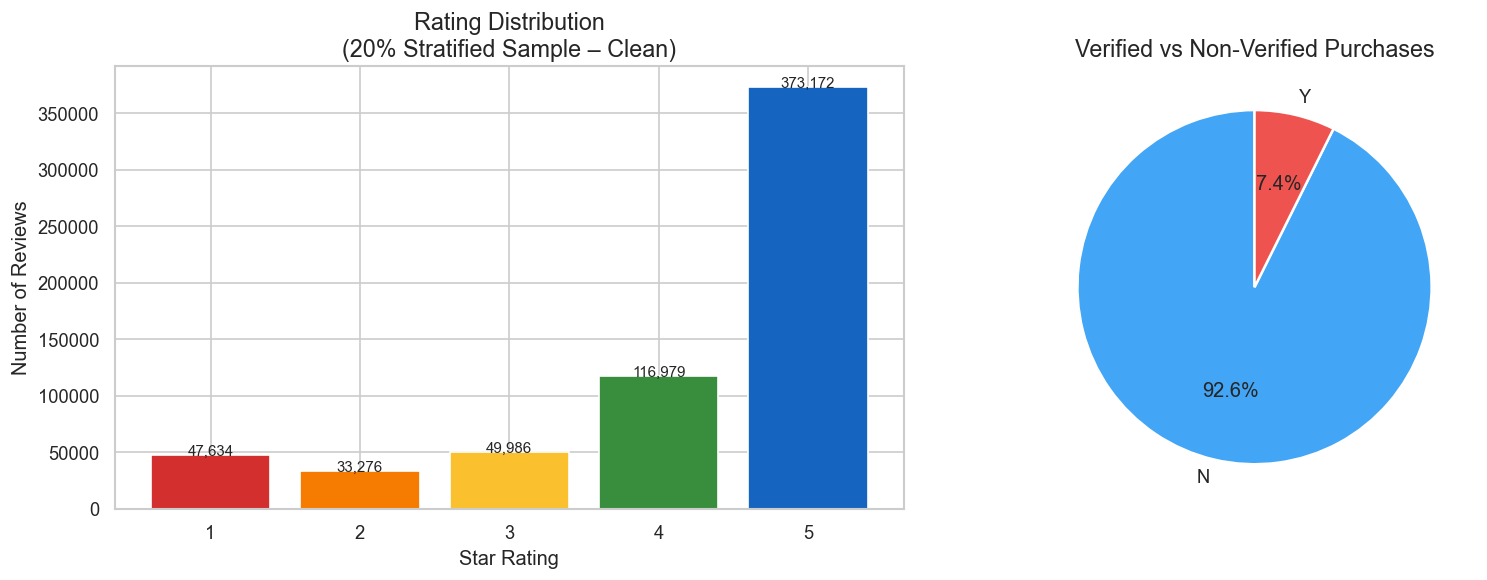

  Saved: fig1_rating_distribution.png


In [10]:
print("\n[3] Descriptive Statistics (clean sampled dataset)")
 
desc = df[['star_rating','review_length','helpful_votes',
           'user_review_count','item_review_count']].describe().round(2)
print(desc)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
rating_counts = df['star_rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0'])
axes[0].set_title('Rating Distribution\n(20% Stratified Sample – Clean)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 100, f'{y:,}', ha='center', fontsize=9)
 
vp_counts = df['verified_purchase'].value_counts()
axes[1].pie(vp_counts.values, labels=vp_counts.index,
            autopct='%1.1f%%', colors=['#42a5f5','#ef5350'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Verified vs Non-Verified Purchases')
 
plt.tight_layout()
plt.savefig('fig1_rating_distribution.png', bbox_inches='tight')
plt.show()
print("  Saved: fig1_rating_distribution.png")

# Natural Noise Analaysis


[4] Natural Noise Analysis

  High-variance users (std ≥ 1.61) : 1,105
  As % of active users                  : 10.0%
  Low-signal reviews (< 20 chars)       : 98 (0.0%)
  Low-helpfulness reviews (ratio < 30%) : 27,129


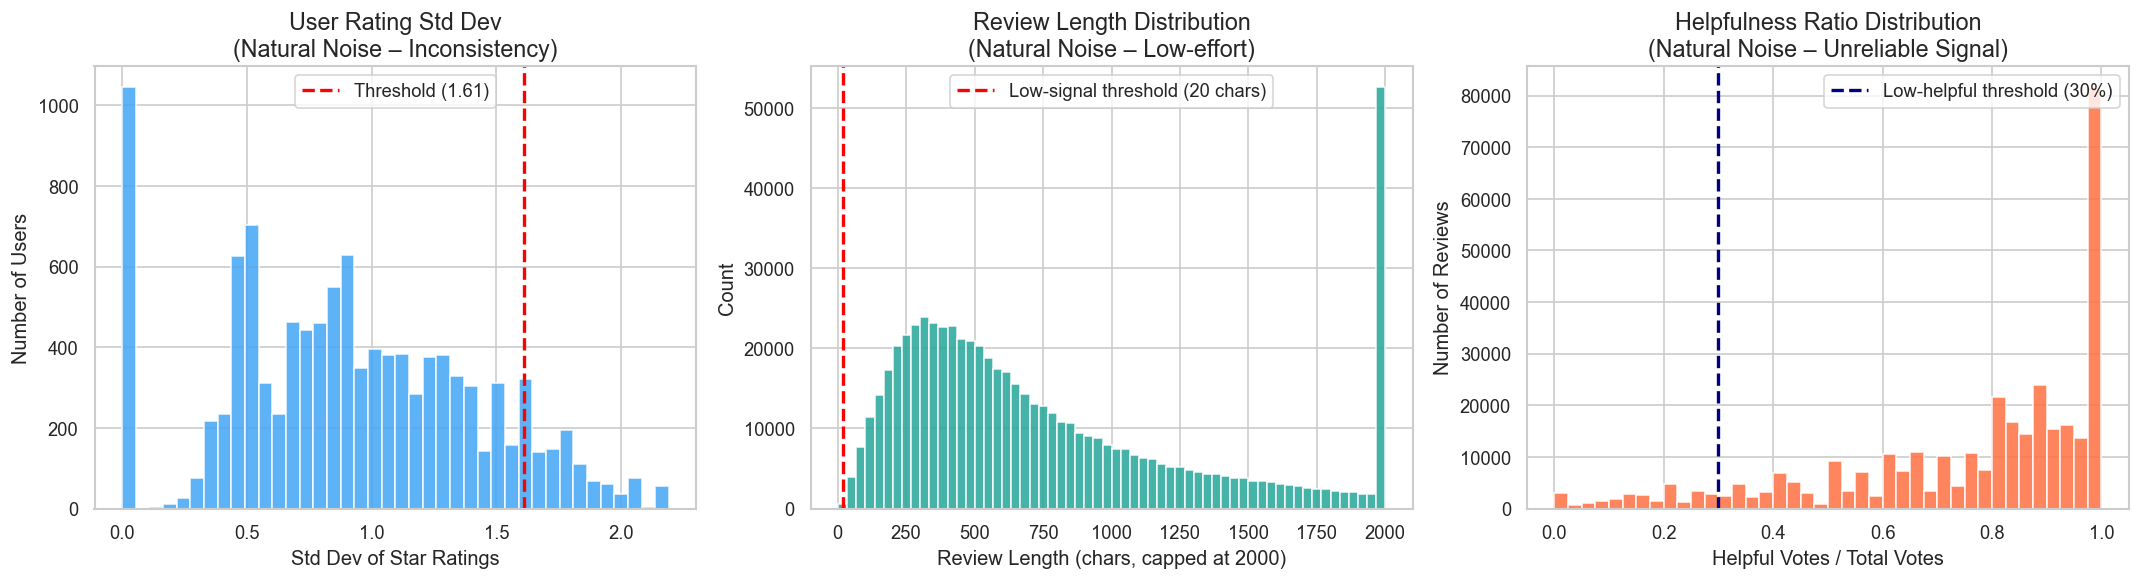

  Saved: fig2_natural_noise_analysis.png


In [11]:
print("\n[4] Natural Noise Analysis")
 
# User-level rating variance (only users with ≥5 reviews)
user_rating_stats = (df.groupby('customer_id')['star_rating']
                     .agg(['mean','std','count']))
user_rating_stats.columns = ['mean_rating','std_rating','review_count']
user_rating_stats = user_rating_stats[user_rating_stats['review_count'] >= 5].dropna()
 
HIGH_VAR_THRESHOLD = user_rating_stats['std_rating'].quantile(0.90)
high_var_users = user_rating_stats[user_rating_stats['std_rating'] >= HIGH_VAR_THRESHOLD]
print(f"\n  High-variance users (std ≥ {HIGH_VAR_THRESHOLD:.2f}) : {len(high_var_users):,}")
print(f"  As % of active users                  : "
      f"{len(high_var_users)/len(user_rating_stats)*100:.1f}%")
 
# Short/low-effort reviews
VERY_SHORT = 20
short_reviews = df[df['review_length'] < VERY_SHORT]
print(f"  Low-signal reviews (< {VERY_SHORT} chars)       : {len(short_reviews):,} "
      f"({len(short_reviews)/len(df)*100:.1f}%)")
 
# Unhelpful reviews (many votes but low helpfulness)
helpful_df  = df[(df['total_votes'] >= 5) & df['helpful_ratio'].notna()].copy()
low_helpful = helpful_df[helpful_df['helpful_ratio'] < 0.30]
print(f"  Low-helpfulness reviews (ratio < 30%) : {len(low_helpful):,}")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].hist(user_rating_stats['std_rating'].dropna(), bins=40,
             color='#42a5f5', edgecolor='white', alpha=0.85)
axes[0].axvline(HIGH_VAR_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold ({HIGH_VAR_THRESHOLD:.2f})')
axes[0].set_title('User Rating Std Dev\n(Natural Noise – Inconsistency)')
axes[0].set_xlabel('Std Dev of Star Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].legend()
 
axes[1].hist(df['review_length'].clip(upper=2000), bins=60,
             color='#26a69a', edgecolor='white', alpha=0.85)
axes[1].axvline(VERY_SHORT, color='red', linestyle='--', linewidth=2,
                label=f'Low-signal threshold ({VERY_SHORT} chars)')
axes[1].set_title('Review Length Distribution\n(Natural Noise – Low-effort)')
axes[1].set_xlabel('Review Length (chars, capped at 2000)')
axes[1].set_ylabel('Count')
axes[1].legend()
 
axes[2].hist(helpful_df['helpful_ratio'], bins=40,
             color='#ff7043', edgecolor='white', alpha=0.85)
axes[2].axvline(0.30, color='navy', linestyle='--', linewidth=2,
                label='Low-helpful threshold (30%)')
axes[2].set_title('Helpfulness Ratio Distribution\n(Natural Noise – Unreliable Signal)')
axes[2].set_xlabel('Helpful Votes / Total Votes')
axes[2].set_ylabel('Number of Reviews')
axes[2].legend()
 
plt.tight_layout()
plt.savefig('fig2_natural_noise_analysis.png', bbox_inches='tight')
plt.show()
print("  Saved: fig2_natural_noise_analysis.png")

# Synthetic Shilling Attack Injection

In [12]:
print("\n[5] Synthetic Shilling Attack Injection")
print("    " + "─" * 55)
 
# Attack parameters 
ATTACK_SIZE_PCT   = 0.03   # ~3% of sample injected as attacks
FILLER_SIZE       = 10     # filler item ratings per fake user profile
N_TARGET_ITEMS    = 5      # number of high-activity items to attack
 
N_ORIGINAL        = len(df)
N_ATTACK_PROFILES = max(50, int(N_ORIGINAL * ATTACK_SIZE_PCT / (FILLER_SIZE + 1)))
 
print(f"\n  Sampled dataset size     : {N_ORIGINAL:,} reviews")
print(f"  Fake profiles per type   : {N_ATTACK_PROFILES:,}")
print(f"  Filler items per profile : {FILLER_SIZE}")
print(f"  Target items attacked    : {N_TARGET_ITEMS}")
 
# Select target and filler items
item_counts   = df.groupby('product_id').size().sort_values(ascending=False)
target_items  = item_counts.head(N_TARGET_ITEMS).index.tolist()
all_items     = df['product_id'].unique().tolist()
global_mean   = float(df['star_rating'].mean())
item_means    = df.groupby('product_id')['star_rating'].mean().astype(float)
 
popular_items = (item_counts[~item_counts.index.isin(target_items)]
                 .head(max(20, int(len(all_items) * 0.05)))
                 .index.tolist())
 
ref_date      = df['review_date'].max()
 
print(f"  Global mean rating       : {global_mean:.2f}")
print(f"  Target items             : {target_items}")
 
# Helper: build one fake review row
fake_id_counter = [0]
 
def make_fake_review(customer_id, product_id, star_rating, noise_type):
    fake_id_counter[0] += 1
    return {
        'marketplace'       : 'US',
        'customer_id'       : customer_id,
        'review_id'         : f'FAKE_{noise_type[:3].upper()}_{fake_id_counter[0]:07d}',
        'product_id'        : product_id,
        'product_category'  : 'Books',
        'star_rating'       : int(star_rating),
        'helpful_votes'     : 0,
        'total_votes'       : 0,
        'vine'              : 'N',
        'verified_purchase' : 'N',
        'review_body'       : 'Highly recommend.',
        'review_date'       : ref_date,
        'review_year'       : ref_date.year,
        'review_length'     : len('Highly recommend.'),
        'helpful_ratio'     : np.nan,
        'user_review_count' : FILLER_SIZE + 1,
        'item_review_count' : np.nan,
        'noise_type'        : noise_type,
        'attack_label'      : 1,
    }


[5] Synthetic Shilling Attack Injection
    ───────────────────────────────────────────────────────

  Sampled dataset size     : 621,047 reviews
  Fake profiles per type   : 1,693
  Filler items per profile : 10
  Target items attacked    : 5
  Global mean rating       : 4.18
  Target items             : ['043935806X', '0439139597', '0525947647', '0385504209', '0895260174']


## Random Attack

In [13]:
print("\n  Injecting Random Attack profiles...")
random_rows = []
for i in range(N_ATTACK_PROFILES):
    uid    = f'FAKE_RAND_{i:06d}'
    target = np.random.choice(target_items)
    random_rows.append(make_fake_review(uid, target, 5, 'random_attack'))
    fillers = np.random.choice(
        [x for x in all_items if x != target], size=FILLER_SIZE, replace=False)
    for fi in fillers:
        r = int(np.clip(np.round(np.random.normal(global_mean, 1.0)), 1, 5))
        random_rows.append(make_fake_review(uid, fi, r, 'random_attack'))
 
df_random = pd.DataFrame(random_rows)
print(f"    Rows injected: {len(df_random):,}")


  Injecting Random Attack profiles...
    Rows injected: 18,623


## Average Attack

In [14]:
print("  Injecting Average Attack profiles...")
average_rows = []
for i in range(N_ATTACK_PROFILES):
    uid    = f'FAKE_AVG_{i:06d}'
    target = np.random.choice(target_items)
    average_rows.append(make_fake_review(uid, target, 5, 'average_attack'))
    fillers = np.random.choice(
        [x for x in all_items if x != target], size=FILLER_SIZE, replace=False)
    for fi in fillers:
        mu = float(item_means.get(fi, global_mean))
        r  = int(np.clip(np.round(np.random.normal(mu, 0.5)), 1, 5))
        average_rows.append(make_fake_review(uid, fi, r, 'average_attack'))
 
df_average = pd.DataFrame(average_rows)
print(f"    Rows injected: {len(df_average):,}")

  Injecting Average Attack profiles...
    Rows injected: 18,623


## Bandwagon Attack

In [15]:
print("  Injecting Bandwagon Attack profiles...")
bandwagon_rows = []
for i in range(N_ATTACK_PROFILES):
    uid    = f'FAKE_BAND_{i:06d}'
    target = np.random.choice(target_items)
    bandwagon_rows.append(make_fake_review(uid, target, 5, 'bandwagon_attack'))
    bw_items = np.random.choice(
        popular_items, size=min(FILLER_SIZE, len(popular_items)), replace=False)
    for bi in bw_items:
        r = int(np.random.choice([4, 5], p=[0.3, 0.7]))
        bandwagon_rows.append(make_fake_review(uid, bi, r, 'bandwagon_attack'))
 
df_bandwagon = pd.DataFrame(bandwagon_rows)
print(f"    Rows injected: {len(df_bandwagon):,}")

  Injecting Bandwagon Attack profiles...
    Rows injected: 18,623


## Merged into combined dataset

In [16]:
df_injected = pd.concat(
    [df, df_random, df_average, df_bandwagon],
    ignore_index=True, sort=False
)
 
# Recalculate item_review_count to reflect injected reviews
new_item_counts = (df_injected.groupby('product_id')['customer_id']
                   .count().rename('item_review_count_new'))
df_injected = (df_injected.drop(columns=['item_review_count'])
               .join(new_item_counts, on='product_id'))
df_injected.rename(columns={'item_review_count_new': 'item_review_count'}, inplace=True)
 
total_injected = len(df_random) + len(df_average) + len(df_bandwagon)
print(f"\n  Total injected rows      : {total_injected:,}")
print(f"  Combined dataset size    : {len(df_injected):,}")
print(f"  Attack proportion        : {total_injected/len(df_injected)*100:.2f}%")


  Total injected rows      : 55,869
  Combined dataset size    : 676,916
  Attack proportion        : 8.25%


## Export injected dataset to CSV

In [17]:
OUTPUT_CSV = 'amazon_reviews_books_with_attacks.csv'
df_injected.to_csv(OUTPUT_CSV, index=False)
file_size_mb = os.path.getsize(OUTPUT_CSV) / (1024 * 1024)
 
print(f"\n  ✅ Exported  : {OUTPUT_CSV}")
print(f"     Rows     : {len(df_injected):,}  |  Size: {file_size_mb:.1f} MB")
print(f"     Key new columns:")
print(f"       noise_type   → original | random_attack | average_attack | bandwagon_attack")
print(f"       attack_label → 0 = genuine review,  1 = injected fake review")


  ✅ Exported  : amazon_reviews_books_with_attacks.csv
     Rows     : 676,916  |  Size: 593.7 MB
     Key new columns:
       noise_type   → original | random_attack | average_attack | bandwagon_attack
       attack_label → 0 = genuine review,  1 = injected fake review


## Injection composition chart

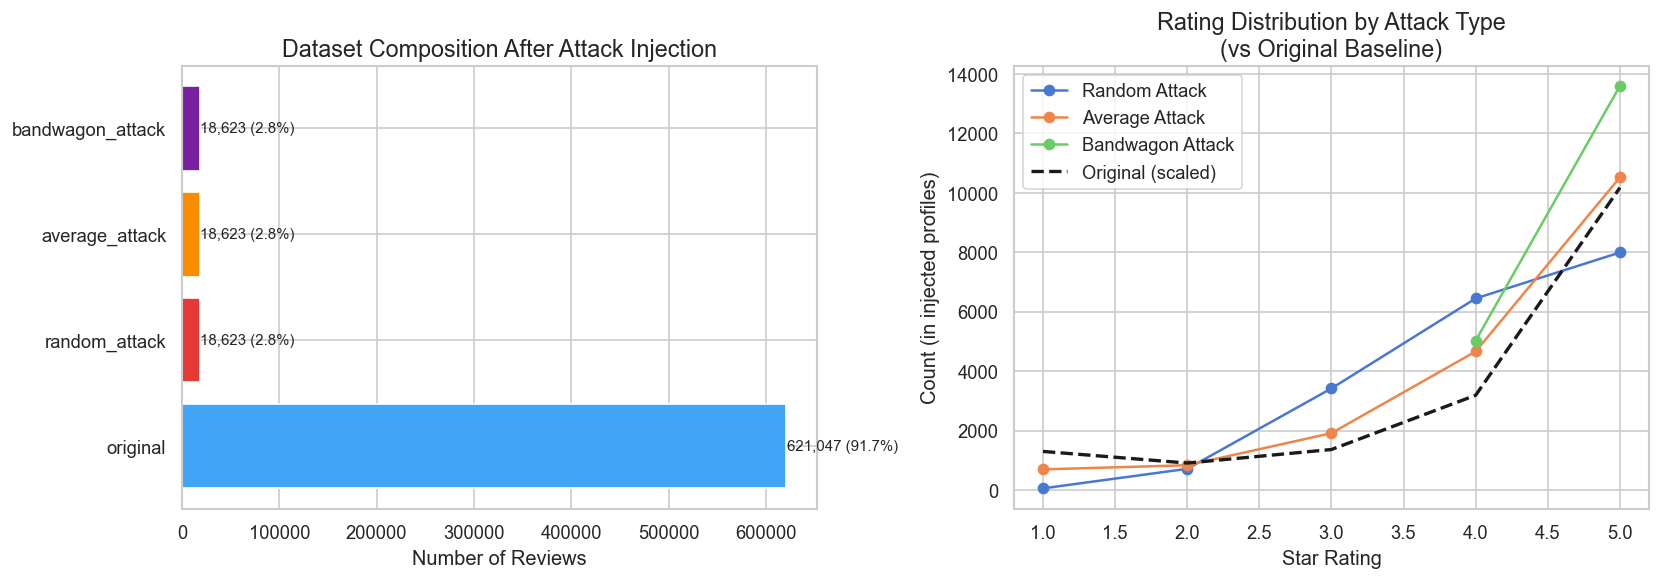

  Saved: fig3_attack_injection_summary.png


In [18]:
inj_summary = df_injected['noise_type'].value_counts().reset_index()
inj_summary.columns = ['noise_type', 'count']
inj_summary['pct']  = inj_summary['count'] / len(df_injected) * 100
 
colors_inj = {
    'original'        : '#42a5f5',
    'random_attack'   : '#e53935',
    'average_attack'  : '#fb8c00',
    'bandwagon_attack': '#7b1fa2'
}
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
bars = axes[0].barh(
    inj_summary['noise_type'], inj_summary['count'],
    color=[colors_inj.get(t,'#aaa') for t in inj_summary['noise_type']],
    edgecolor='white'
)
axes[0].set_title('Dataset Composition After Attack Injection')
axes[0].set_xlabel('Number of Reviews')
for bar, row in zip(bars, inj_summary.itertuples()):
    axes[0].text(bar.get_width() + 200,
                 bar.get_y() + bar.get_height()/2,
                 f'{row.count:,} ({row.pct:.1f}%)', va='center', fontsize=9)
 
attack_only = df_injected[df_injected['attack_label'] == 1]
for atk in ['random_attack','average_attack','bandwagon_attack']:
    sub = (attack_only[attack_only['noise_type'] == atk]['star_rating']
           .value_counts().sort_index())
    axes[1].plot(sub.index, sub.values, marker='o',
                 label=atk.replace('_',' ').title())
orig_dist = (df['star_rating'].value_counts().sort_index()
             / len(df) * (N_ATTACK_PROFILES * FILLER_SIZE))
axes[1].plot(orig_dist.index, orig_dist.values, 'k--',
             linewidth=2, label='Original (scaled)')
axes[1].set_title('Rating Distribution by Attack Type\n(vs Original Baseline)')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Count (in injected profiles)')
axes[1].legend()
 
plt.tight_layout()
plt.savefig('fig3_attack_injection_summary.png', bbox_inches='tight')
plt.show()
print("  Saved: fig3_attack_injection_summary.png")

# Load injected dataset and verify

In [19]:
print("\n[6] Loading & Verifying Injected Dataset from CSV...")
 
# Re-load with same memory optimisations
df_work = pd.read_csv(OUTPUT_CSV, low_memory=False)
df_work['review_date'] = pd.to_datetime(df_work['review_date'], errors='coerce')
df_work['star_rating'] = pd.to_numeric(df_work['star_rating'], errors='coerce').astype('Int8')
df_work['helpful_votes'] = pd.to_numeric(df_work['helpful_votes'], errors='coerce').fillna(0).astype('int32')
df_work['total_votes']   = pd.to_numeric(df_work['total_votes'],   errors='coerce').fillna(0).astype('int32')
df_work['review_length'] = pd.to_numeric(df_work['review_length'], errors='coerce').fillna(0).astype('int32')
 
for col in ['verified_purchase', 'marketplace', 'product_category', 'noise_type']:
    if col in df_work.columns:
        df_work[col] = df_work[col].astype('category')
 
report_memory(df_work, 'injected dataset after load')
 
print(f"\n  Shape                : {df_work.shape[0]:,} rows × {df_work.shape[1]} columns")
print(f"\n  Noise type counts:\n{df_work['noise_type'].value_counts()}")
print(f"\n  Attack label counts:\n{df_work['attack_label'].value_counts()}")
print(f"\n  Sample of injected rows:")
print(df_work[df_work['attack_label'] == 1][
    ['customer_id','product_id','star_rating','noise_type','verified_purchase']
].head(6).to_string(index=False))


[6] Loading & Verifying Injected Dataset from CSV...
  Memory usage injected dataset after load: 787.5 MB  (676,916 rows)

  Shape                : 676,916 rows × 19 columns

  Noise type counts:
noise_type
original            621047
average_attack       18623
bandwagon_attack     18623
random_attack        18623
Name: count, dtype: int64

  Attack label counts:
attack_label
0    621047
1     55869
Name: count, dtype: int64

  Sample of injected rows:
     customer_id product_id  star_rating    noise_type verified_purchase
FAKE_RAND_000000 0385504209            5 random_attack                 N
FAKE_RAND_000000 1591254779            4 random_attack                 N
FAKE_RAND_000000 0060193395            5 random_attack                 N
FAKE_RAND_000000 0375705252            4 random_attack                 N
FAKE_RAND_000000 0766107671            3 random_attack                 N
FAKE_RAND_000000 0425109305            4 random_attack                 N


# Noise impact analysis


[7] Noise Impact Analysis – Rating Distortion on Target Items

  Rating Shift per Target Item per Attack Type:
   product_id      attack_type  original_mean  combined_mean  rating_shift  n_injected
043935806X...    Random Attack          4.409          4.568         0.159         340
043935806X...   Average Attack          4.409          4.567         0.157         336
043935806X... Bandwagon Attack          4.409          4.569         0.160         344
0439139597...    Random Attack          4.798          4.861         0.062         352
0439139597...   Average Attack          4.798          4.859         0.061         340
0439139597... Bandwagon Attack          4.798          4.857         0.058         320
0525947647...    Random Attack          3.877          4.309         0.432         330
0525947647...   Average Attack          3.877          4.313         0.436         335
0525947647... Bandwagon Attack          3.877          4.322         0.445         346
0385504209...    R

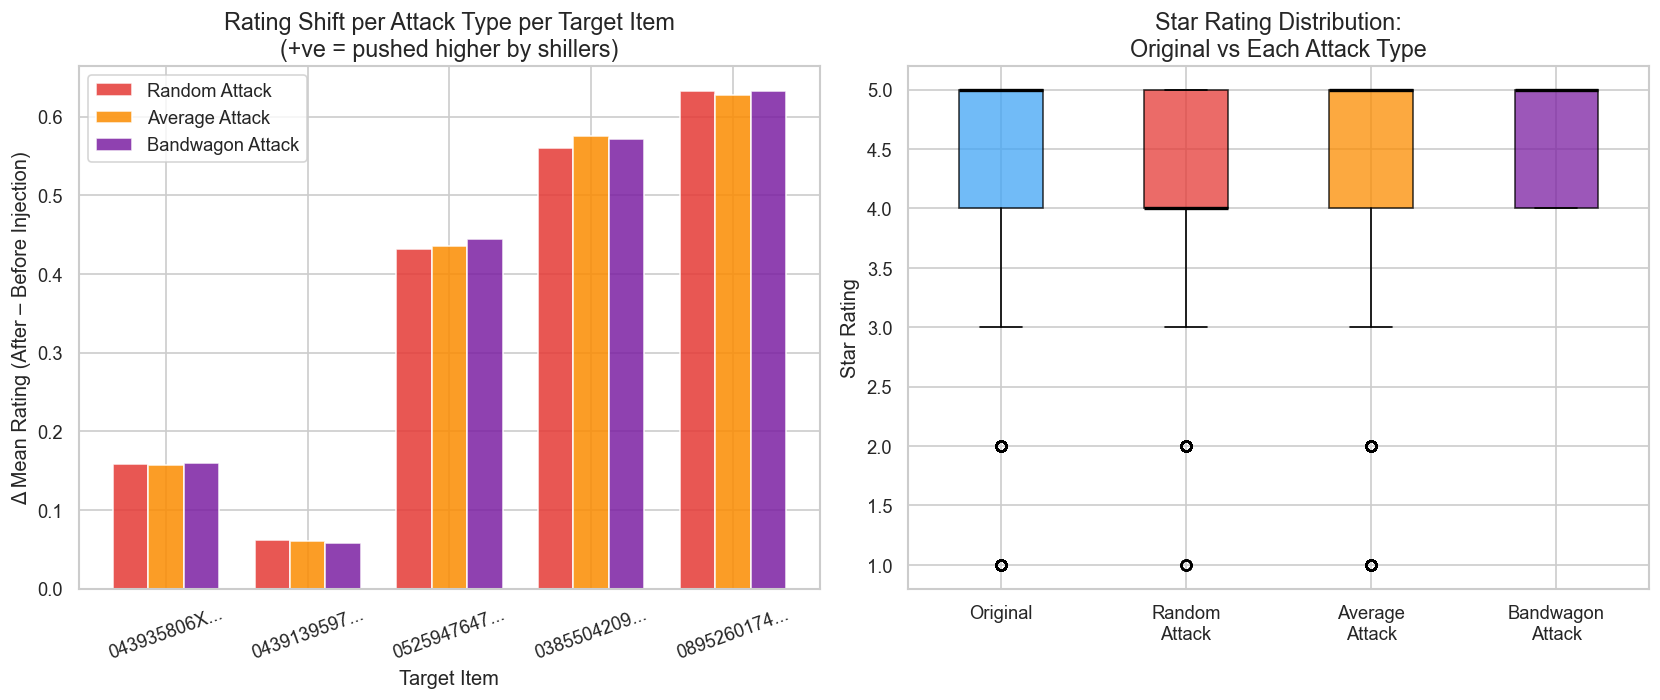

  Saved: fig4_noise_impact_rating_shift.png


In [20]:
print("\n[7] Noise Impact Analysis – Rating Distortion on Target Items")
 
impact_rows = []
for item in target_items:
    orig_mean = float(df[df['product_id'] == item]['star_rating'].mean())
    for atk in ['random_attack','average_attack','bandwagon_attack']:
        atk_ratings = df_work[
            (df_work['product_id'] == item) & (df_work['noise_type'] == atk)
        ]['star_rating'].dropna()
        combined_mean = float(pd.concat([
            df[df['product_id'] == item]['star_rating'],
            atk_ratings
        ]).mean())
        impact_rows.append({
            'product_id'    : item[:12] + '...',
            'attack_type'   : atk.replace('_',' ').title(),
            'original_mean' : round(orig_mean, 3),
            'combined_mean' : round(combined_mean, 3),
            'rating_shift'  : round(combined_mean - orig_mean, 3),
            'n_injected'    : len(atk_ratings),
        })
 
impact_df = pd.DataFrame(impact_rows)
print("\n  Rating Shift per Target Item per Attack Type:")
print(impact_df.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
atk_color = {'Random Attack':'#e53935','Average Attack':'#fb8c00',
             'Bandwagon Attack':'#7b1fa2'}
 
x_pos  = np.arange(len(target_items))
width  = 0.25
atk_list = ['Random Attack','Average Attack','Bandwagon Attack']
offsets  = [-width, 0, width]
 
for atk, offset in zip(atk_list, offsets):
    vals = [impact_df[(impact_df['attack_type']==atk) &
                      (impact_df['product_id']==t[:12]+'...')]['rating_shift'].values[0]
            for t in target_items]
    axes[0].bar(x_pos + offset, vals, width,
                label=atk, color=atk_color[atk], edgecolor='white', alpha=0.85)
 
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Rating Shift per Attack Type per Target Item\n(+ve = pushed higher by shillers)')
axes[0].set_xlabel('Target Item')
axes[0].set_ylabel('Δ Mean Rating (After – Before Injection)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([t[:10]+'...' for t in target_items], rotation=20)
axes[0].legend()
 
plot_data   = []
plot_labels = []
for nt in ['original','random_attack','average_attack','bandwagon_attack']:
    sub = df_work[df_work['noise_type'] == nt]['star_rating'].dropna()
    plot_data.append(sub.astype(float).values)
    plot_labels.append(nt.replace('_','\n').title())
 
bp = axes[1].boxplot(plot_data, labels=plot_labels, patch_artist=True,
                     medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], ['#42a5f5','#e53935','#fb8c00','#7b1fa2']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Star Rating Distribution:\nOriginal vs Each Attack Type')
axes[1].set_ylabel('Star Rating')
 
plt.tight_layout()
plt.savefig('fig4_noise_impact_rating_shift.png', bbox_inches='tight')
plt.show()
print("  Saved: fig4_noise_impact_rating_shift.png")

# Before and after rating count per targer item


[8] Before vs After Rating Analysis per Target Item


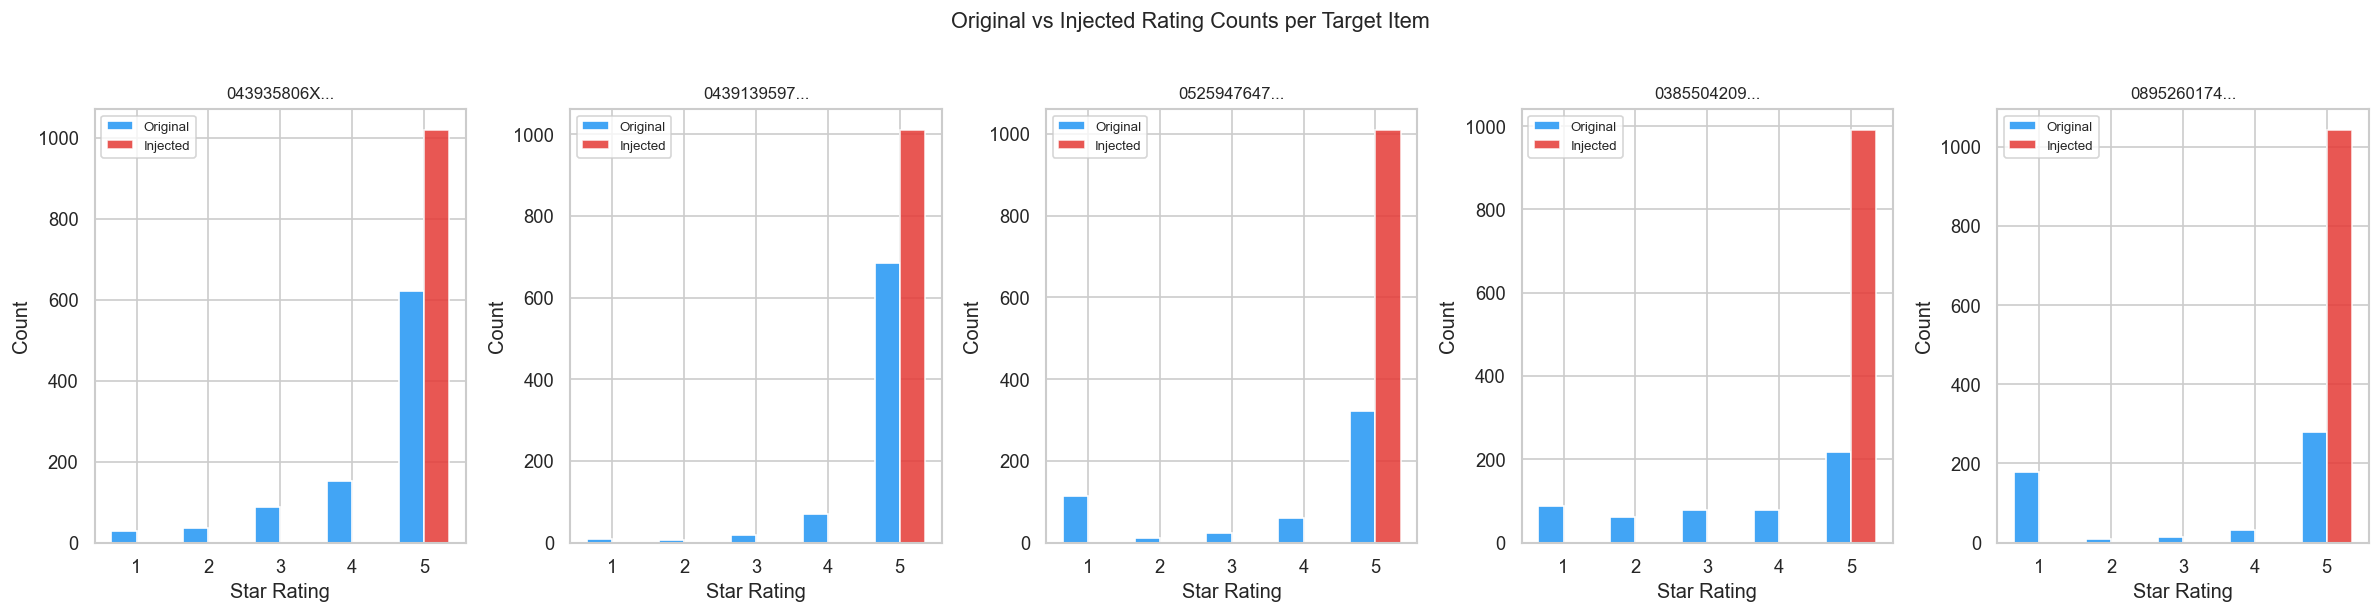

  Saved: fig5_before_after_target_items.png


In [21]:
print("\n[8] Before vs After Rating Analysis per Target Item")
 
fig, axes = plt.subplots(1, len(target_items),
                         figsize=(4 * len(target_items), 5))
if len(target_items) == 1:
    axes = [axes]
 
for ax, item in zip(axes, target_items):
    orig_rc = df[df['product_id'] == item]['star_rating'].value_counts().sort_index()
    inj_rc  = df_work[
        (df_work['product_id'] == item) & (df_work['attack_label'] == 1)
    ]['star_rating'].value_counts().sort_index()
 
    x = np.array([1,2,3,4,5])
    w = 0.35
    ax.bar(x - w/2, [orig_rc.get(r,0) for r in x], w,
           label='Original', color='#42a5f5', edgecolor='white')
    ax.bar(x + w/2, [inj_rc.get(r,0)  for r in x], w,
           label='Injected',  color='#e53935', edgecolor='white', alpha=0.85)
    ax.set_title(f'{item[:10]}...', fontsize=10)
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.set_xticks(x)
 
plt.suptitle('Original vs Injected Rating Counts per Target Item',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig5_before_after_target_items.png', bbox_inches='tight')
plt.show()
print("  Saved: fig5_before_after_target_items.png")

# Composite noise risk scoring


[9] Composite Noise Risk Scoring (on injected dataset)

  Noise Score Distribution (injected dataset):
    Score 0:   15,769  █
    Score 1:  205,810  ████████████████
    Score 2:  383,892  ██████████████████████████████
    Score 3:   38,590  ███
    Score 4:   32,855  ██

  Mean noise score: genuine vs injected:
                 count  mean   std  min  25%  50%  75%  max
attack_label                                               
0             621047.0  1.64  0.57  0.0  1.0  2.0  2.0  3.0
1              55869.0  3.59  0.49  3.0  3.0  4.0  4.0  4.0

  High-risk reviews (score ≥ 3) : 71,445
  Of those, % that are injected     : 78.2%


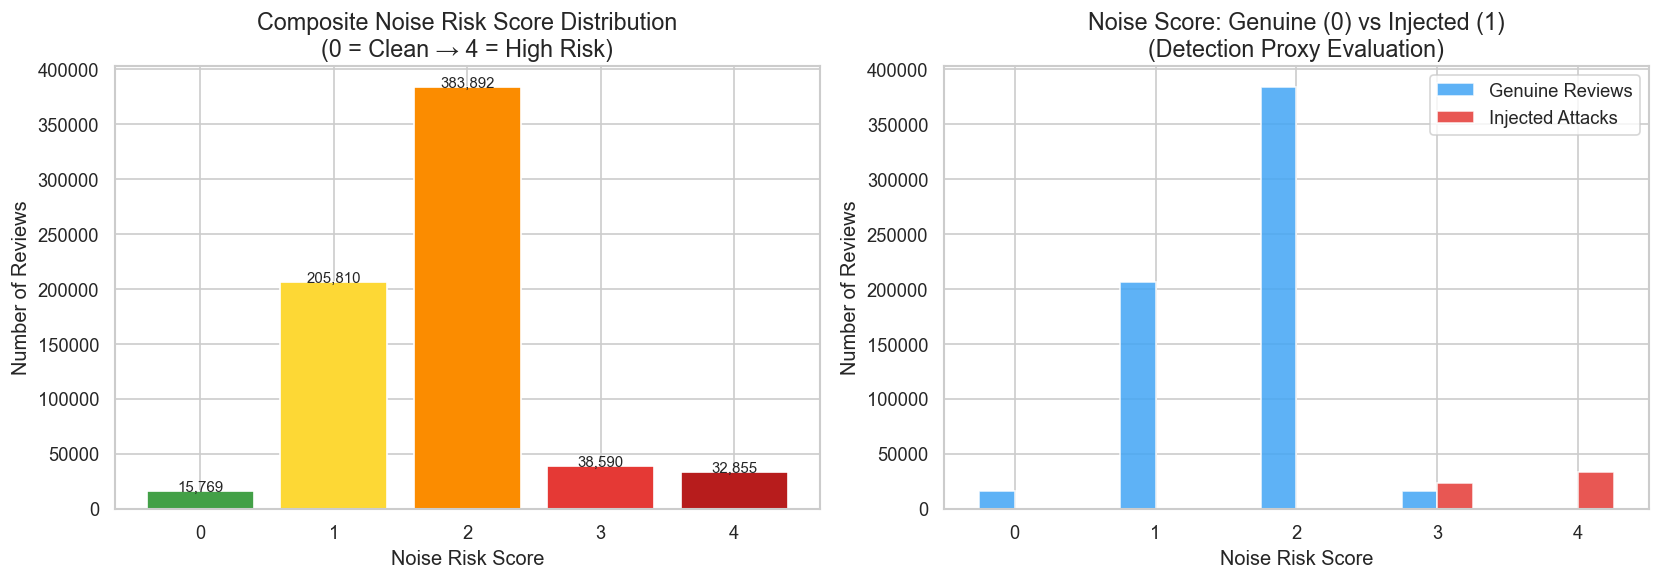

  Saved: fig6_composite_noise_score.png


In [22]:
print("\n[9] Composite Noise Risk Scoring (on injected dataset)")
 
df_work['review_day'] = df_work['review_date'].dt.date
daily_user      = (df_work.groupby(['customer_id','review_day'])
                   .size().reset_index(name='reviews_in_day'))
burst_users_set = set(daily_user[daily_user['reviews_in_day'] >= 5]['customer_id'])
 
df_work['score_nonverif'] = (df_work['verified_purchase'].astype(str)
                              .str.upper().eq('N').astype('int8'))
df_work['score_extreme']  = df_work['star_rating'].isin([1,5]).astype('int8')
df_work['score_short']    = (df_work['review_length'].fillna(0) < VERY_SHORT).astype('int8')
df_work['score_burst']    = df_work['customer_id'].isin(burst_users_set).astype('int8')
 
df_work['noise_score'] = (df_work['score_nonverif'] + df_work['score_extreme'] +
                          df_work['score_short']    + df_work['score_burst']).astype('int8')
 
noise_dist = df_work['noise_score'].value_counts().sort_index()
print("\n  Noise Score Distribution (injected dataset):")
for score, count in noise_dist.items():
    bar = '█' * int(count / noise_dist.max() * 30)
    print(f"    Score {score}: {count:>8,}  {bar}")
 
print("\n  Mean noise score: genuine vs injected:")
print(df_work.groupby('attack_label')['noise_score'].describe().round(2))
 
HIGH_RISK_SCORE = 3
high_risk       = df_work[df_work['noise_score'] >= HIGH_RISK_SCORE]
precision_at_3  = high_risk['attack_label'].mean() * 100
print(f"\n  High-risk reviews (score ≥ {HIGH_RISK_SCORE}) : {len(high_risk):,}")
print(f"  Of those, % that are injected     : {precision_at_3:.1f}%")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
palette = ['#43a047','#fdd835','#fb8c00','#e53935','#b71c1c']
axes[0].bar(noise_dist.index, noise_dist.values,
            color=palette[:len(noise_dist)], edgecolor='white')
axes[0].set_title('Composite Noise Risk Score Distribution\n(0 = Clean → 4 = High Risk)')
axes[0].set_xlabel('Noise Risk Score')
axes[0].set_ylabel('Number of Reviews')
for x, y in zip(noise_dist.index, noise_dist.values):
    axes[0].text(x, y + 200, f'{y:,}', ha='center', fontsize=9)
 
score_by_label = (df_work.groupby(['attack_label','noise_score'])
                  .size().unstack(fill_value=0))
score_by_label.T.plot(kind='bar', ax=axes[1],
                      color=['#42a5f5','#e53935'], edgecolor='white', alpha=0.85)
axes[1].set_title('Noise Score: Genuine (0) vs Injected (1)\n(Detection Proxy Evaluation)')
axes[1].set_xlabel('Noise Risk Score')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend(['Genuine Reviews','Injected Attacks'])
axes[1].tick_params(axis='x', rotation=0)
 
plt.tight_layout()
plt.savefig('fig6_composite_noise_score.png', bbox_inches='tight')
plt.show()
print("  Saved: fig6_composite_noise_score.png")

# Item level susceptibility - Injected dataset


[10] Item-Level Noise Susceptibility
  Items with ≥10 reviews   : 8,152
  Highly susceptible items : 903 (mean noise score ≥ 2.20)

  Top 10 most susceptible:
product_id  total_reviews  mean_rating  pct_injected  mean_noise_score
0895260174           1557     4.485549      0.670520          3.285164
0525947647           1539     4.614685      0.656920          3.231319
0385504209           1515     4.492409      0.654785          3.149835
0439139597           1801     4.911716      0.561910          3.037202
1569714010             11     4.818182      0.454545          2.909091
1885106823             10          4.8      0.300000          2.900000
0375407561             10          5.0      0.400000          2.900000
043935806X           1946     4.718911      0.524152          2.871017
0765306905             12     4.833333      0.500000          2.833333
0823016285             11          5.0      0.454545          2.818182


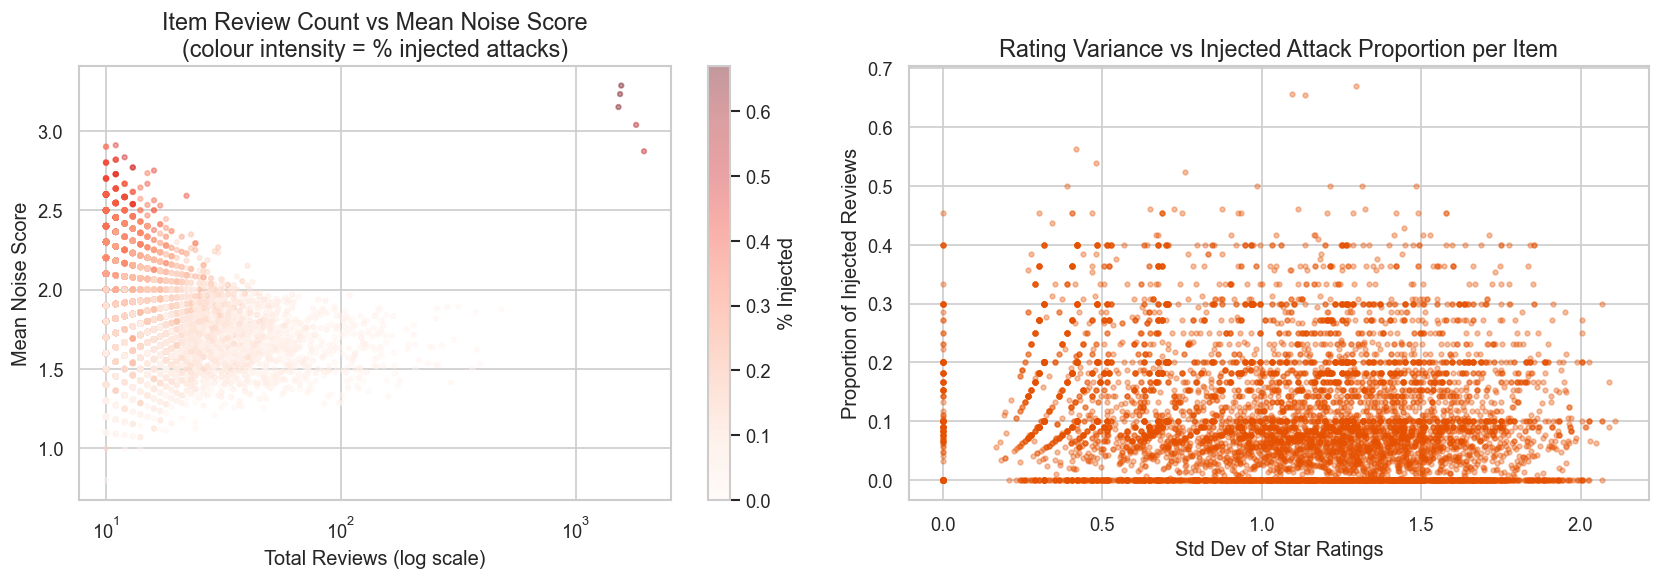

  Saved: fig7_item_susceptibility.png


In [23]:
print("\n[10] Item-Level Noise Susceptibility")
 
item_noise = df_work.groupby('product_id').agg(
    total_reviews    = ('star_rating', 'count'),
    mean_rating      = ('star_rating', 'mean'),
    std_rating       = ('star_rating', 'std'),
    pct_nonverif     = ('score_nonverif', 'mean'),
    pct_extreme      = ('score_extreme',  'mean'),
    mean_noise_score = ('noise_score',    'mean'),
    pct_injected     = ('attack_label',   'mean'),
).reset_index()
 
item_noise = item_noise[item_noise['total_reviews'] >= 10]
SUSCEPTIBLE_THRESHOLD = item_noise['mean_noise_score'].quantile(0.90)
susceptible_items = item_noise[item_noise['mean_noise_score'] >= SUSCEPTIBLE_THRESHOLD]
 
print(f"  Items with ≥10 reviews   : {len(item_noise):,}")
print(f"  Highly susceptible items : {len(susceptible_items):,} "
      f"(mean noise score ≥ {SUSCEPTIBLE_THRESHOLD:.2f})")
print(f"\n  Top 10 most susceptible:")
print(susceptible_items.sort_values('mean_noise_score', ascending=False)
      [['product_id','total_reviews','mean_rating','pct_injected','mean_noise_score']]
      .head(10).to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sc = axes[0].scatter(item_noise['total_reviews'], item_noise['mean_noise_score'],
                     c=item_noise['pct_injected'], cmap='Reds', alpha=0.4, s=8)
axes[0].set_xscale('log')
axes[0].set_title('Item Review Count vs Mean Noise Score\n(colour intensity = % injected attacks)')
axes[0].set_xlabel('Total Reviews (log scale)')
axes[0].set_ylabel('Mean Noise Score')
plt.colorbar(sc, ax=axes[0], label='% Injected')
 
axes[1].scatter(item_noise['std_rating'], item_noise['pct_injected'],
                alpha=0.35, s=8, c='#e65100')
axes[1].set_title('Rating Variance vs Injected Attack Proportion per Item')
axes[1].set_xlabel('Std Dev of Star Ratings')
axes[1].set_ylabel('Proportion of Injected Reviews')
 
plt.tight_layout()
plt.savefig('fig7_item_susceptibility.png', bbox_inches='tight')
plt.show()
print("  Saved: fig7_item_susceptibility.png")

# Final Summary

In [24]:
print("\n[11] FINAL SUMMARY")
print("=" * 68)
print(f"  Sample rate                       : 1 in {SAMPLE_EVERY_NTH} rows (~{100//SAMPLE_EVERY_NTH}% stratified)")
print(f"  Sampled (clean) dataset           : {N_ORIGINAL:,} reviews")
print(f"  Combined injected dataset         : {len(df_work):,} reviews")
print(f"  Exported CSV                      : {OUTPUT_CSV}  ({file_size_mb:.1f} MB)")
print()
print("  ── MEMORY OPTIMISATION ───────────────────────────────────────")
print(f"  Columns dropped at load           : review_headline, product_title, product_parent")
print(f"  Dtypes downcasted                 : star_rating→int8, votes→int32, categories→category")
print()
print("  ── NATURAL NOISE ─────────────────────────────────────────────")
print(f"  High-variance users (std ≥ {HIGH_VAR_THRESHOLD:.2f})  : {len(high_var_users):,}")
print(f"  Low-signal reviews (< {VERY_SHORT} chars)     : {len(short_reviews):,} ({len(short_reviews)/N_ORIGINAL*100:.1f}%)")
print(f"  Low-helpfulness reviews           : {len(low_helpful):,}")
print()
print("  ── SYNTHETIC SHILLING ATTACKS INJECTED ───────────────────────")
print(f"  Random Attack profiles            : {N_ATTACK_PROFILES:,} → {len(df_random):,} reviews")
print(f"  Average Attack profiles           : {N_ATTACK_PROFILES:,} → {len(df_average):,} reviews")
print(f"  Bandwagon Attack profiles         : {N_ATTACK_PROFILES:,} → {len(df_bandwagon):,} reviews")
print(f"  Total injected                    : {total_injected:,} ({total_injected/len(df_work)*100:.2f}%)")
print()
print("  ── TARGET ITEM DISTORTION ────────────────────────────────────")
avg_shift = impact_df['rating_shift'].abs().mean()
max_shift = impact_df['rating_shift'].abs().max()
print(f"  Mean absolute rating shift        : {avg_shift:.3f} stars")
print(f"  Max rating shift observed         : {max_shift:.3f} stars")
print()
print("  ── NOISE DETECTION PROXY ─────────────────────────────────────")
print(f"  High-risk reviews (score ≥ {HIGH_RISK_SCORE})      : {len(high_risk):,}")
print(f"  % of flagged that are injected    : {precision_at_3:.1f}%")
print(f"  Noise-susceptible items           : {len(susceptible_items):,}")
print("=" * 68)
 
print("""
  RELEVANCE TO UNRR FRAMEWORK:
  ─────────────────────────────────────────────────────────────────
  The injected CSV (amazon_reviews_books_with_attacks.csv) contains
  BOTH natural noise AND labelled malicious noise (3 attack types).
 
  This enables the UNRR framework to:
 
  1. TRAIN noise-aware models in a realistic mixed-noise environment
     using attack_label as ground-truth supervision.
 
  2. EVALUATE robustness by comparing recommender performance on
     clean vs injected datasets per attack type.
 
  3. DEVELOP noise reweighting: use noise_score as a confidence
     weight — high-score reviews are down-weighted during training.
 
  4. BENCHMARK detection: the noise_score separation between genuine
     and injected reviews (Section 9) forms the UNRR detection baseline.
 
  NOTE ON SAMPLING:
  A stratified 20% sample was used due to memory constraints. This
  preserves the distributional properties of the full dataset and is
  standard practice in academic recommender system research.
""")
 
print("[DONE] All 7 figures saved. Injected CSV exported. Interim v3 complete.")


[11] FINAL SUMMARY
  Sample rate                       : 1 in 5 rows (~20% stratified)
  Sampled (clean) dataset           : 621,047 reviews
  Combined injected dataset         : 676,916 reviews
  Exported CSV                      : amazon_reviews_books_with_attacks.csv  (593.7 MB)

  ── MEMORY OPTIMISATION ───────────────────────────────────────
  Columns dropped at load           : review_headline, product_title, product_parent
  Dtypes downcasted                 : star_rating→int8, votes→int32, categories→category

  ── NATURAL NOISE ─────────────────────────────────────────────
  High-variance users (std ≥ 1.61)  : 1,105
  Low-signal reviews (< 20 chars)     : 98 (0.0%)
  Low-helpfulness reviews           : 27,129

  ── SYNTHETIC SHILLING ATTACKS INJECTED ───────────────────────
  Random Attack profiles            : 1,693 → 18,623 reviews
  Average Attack profiles           : 1,693 → 18,623 reviews
  Bandwagon Attack profiles         : 1,693 → 18,623 reviews
  Total injected      